<a href="https://colab.research.google.com/github/Srivaibhav4014e/Data-science-/blob/main/Social%20network%20graphs%20%26%20community%20detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

=== Network Statistics ===
Nodes:                10
Edges:                13
Density:              0.2889
Is connected:         True
Avg Clustering Coeff: 0.6667
Diameter:             6
Avg Shortest Path:    2.7111

Node Degrees (sorted):
  Alice   : 3
  Carol   : 3
  Dave    : 3
  Eve     : 3
  Grace   : 3
  Hank    : 3
  Bob     : 2
  Frank   : 2
  Ivy     : 2
  Jack    : 2

Girvan-Newman Communities:
  Community 1: ['Alice', 'Bob', 'Carol', 'Dave']
  Community 2: ['Eve', 'Frank', 'Grace', 'Hank', 'Ivy', 'Jack']

Greedy Modularity Communities:
  Community 1: ['Alice', 'Bob', 'Carol', 'Dave']
  Community 2: ['Eve', 'Frank', 'Grace']
  Community 3: ['Hank', 'Ivy', 'Jack']


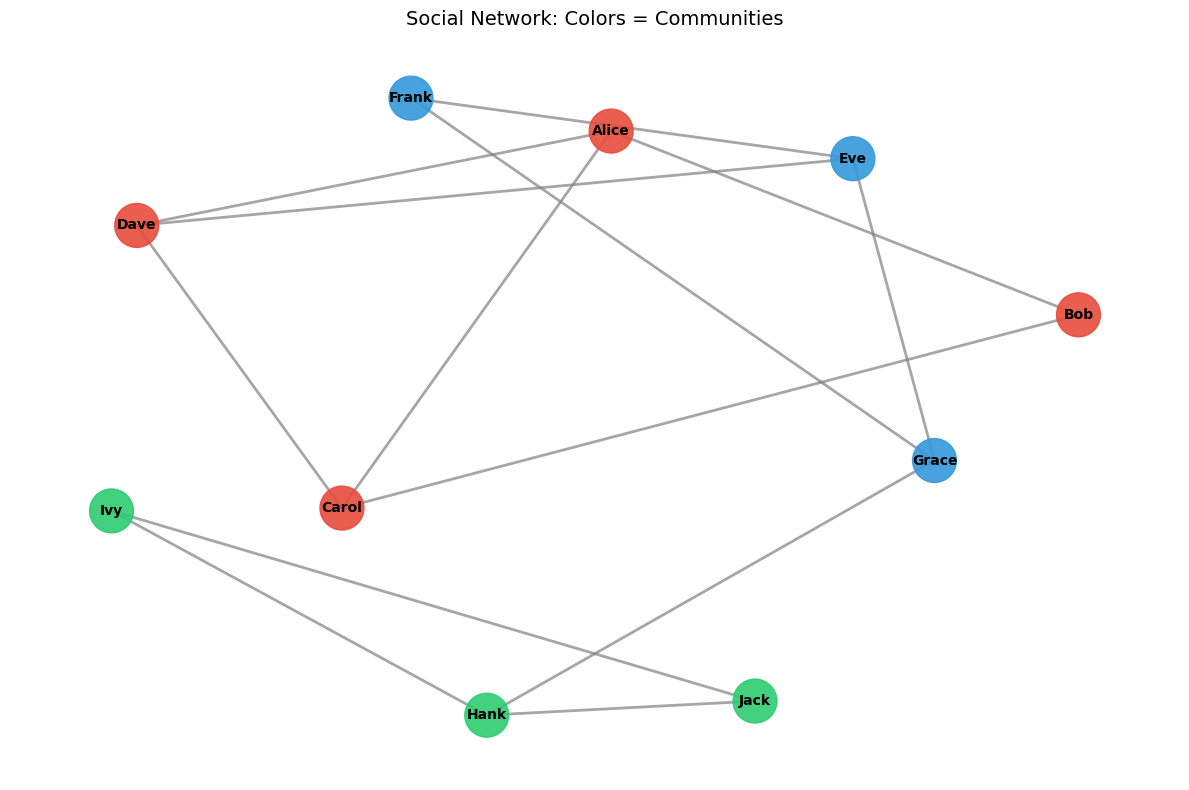


Barabasi-Albert avg degree: 3.84


In [ ]:

import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ── Build Social Network ─────────────────────────
G = nx.Graph()

# Nodes represent people
people = ['Alice','Bob','Carol','Dave','Eve',
          'Frank','Grace','Hank','Ivy','Jack']
G.add_nodes_from(people)

# Edges represent friendships
edges = [
    ('Alice','Bob'), ('Alice','Carol'), ('Alice','Dave'),
    ('Bob','Carol'), ('Carol','Dave'),
    ('Eve','Frank'), ('Eve','Grace'), ('Frank','Grace'),
    ('Hank','Ivy'),  ('Hank','Jack'),  ('Ivy','Jack'),
    ('Dave','Eve'),  ('Grace','Hank')   # Bridge edges
]
G.add_edges_from(edges)

# ── Graph Statistics ─────────────────────────────
print('=== Network Statistics ===')
print(f'Nodes:                {G.number_of_nodes()}')
print(f'Edges:                {G.number_of_edges()}')
print(f'Density:              {nx.density(G):.4f}')
print(f'Is connected:         {nx.is_connected(G)}')
print(f'Avg Clustering Coeff: {nx.average_clustering(G):.4f}')
print(f'Diameter:             {nx.diameter(G)}')
print(f'Avg Shortest Path:    {nx.average_shortest_path_length(G):.4f}')

print('\nNode Degrees (sorted):')
for node, deg in sorted(G.degree(), key=lambda x:-x[1]):
    print(f'  {node:8s}: {deg}')

# ── Community Detection — Girvan Newman ──────────
from networkx.algorithms.community import girvan_newman
comp = girvan_newman(G)
communities_gn = next(comp)      # First split
print('\nGirvan-Newman Communities:')
for i, comm in enumerate(communities_gn):
    print(f'  Community {i+1}: {sorted(comm)}')

# ── Community Detection — Greedy Modularity ──────
from networkx.algorithms.community import greedy_modularity_communities
communities_gm = list(greedy_modularity_communities(G))
print('\nGreedy Modularity Communities:')
for i, comm in enumerate(communities_gm):
    print(f'  Community {i+1}: {sorted(comm)}')

# ── Visualize ────────────────────────────────────
pos = nx.spring_layout(G, seed=42, k=2.0)
color_map = ['#E74C3C','#3498DB','#2ECC71','#F39C12','#9B59B6']
node_colors = []
for node in G.nodes():
    for i, comm in enumerate(communities_gm):
        if node in comm:
            node_colors.append(color_map[i % len(color_map)])
            break

plt.figure(figsize=(12,8))
nx.draw_networkx_nodes(G, pos, node_size=1000,
                        node_color=node_colors, alpha=0.9)
nx.draw_networkx_edges(G, pos, width=2, alpha=0.7,
                        edge_color='gray')
nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')
plt.title('Social Network: Colors = Communities', fontsize=14)
plt.axis('off'); plt.tight_layout(); plt.show()

# ── Common Real-World Graph Types ────────────────
G_ba   = nx.barabasi_albert_graph(50, 2)  # Scale-free (internet)
G_ws   = nx.watts_strogatz_graph(50, 4, 0.3)  # Small world
G_er   = nx.erdos_renyi_graph(50, 0.1)   # Random graph
print('\nBarabasi-Albert avg degree:',
      sum(d for n,d in G_ba.degree())/G_ba.number_of_nodes())